In [1]:
import os
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
print(os.listdir("/kaggle/input"))

DATASET_PATH = "/kaggle/input/datasets/kayanalmesned/saudird"
WORK_PATH = "/kaggle/working/saudird_binary"

print(os.listdir(DATASET_PATH))

['datasets']
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']


In [3]:
if os.path.exists(WORK_PATH):
    shutil.rmtree(WORK_PATH)

for split in ["train", "valid", "test"]:
    os.makedirs(f"{WORK_PATH}/{split}/damage", exist_ok=True)
    os.makedirs(f"{WORK_PATH}/{split}/no_damage", exist_ok=True)

    img_dir = f"{DATASET_PATH}/{split}/images"
    lbl_dir = f"{DATASET_PATH}/{split}/labels"

    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(lbl_dir, label_name)

        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            target_class = "damage"
        else:
            target_class = "no_damage"

        shutil.copy(
            os.path.join(img_dir, img_name),
            f"{WORK_PATH}/{split}/{target_class}/{img_name}"
        )

print("Dataset converted successfully.")

for split in ["train", "valid", "test"]:
    print(split.upper())
    print("Damage:", len(os.listdir(f"{WORK_PATH}/{split}/damage")))
    print("No Damage:", len(os.listdir(f"{WORK_PATH}/{split}/no_damage")))
    print("-" * 30)

Dataset converted successfully.
TRAIN
Damage: 1476
No Damage: 984
------------------------------
VALID
Damage: 81
No Damage: 53
------------------------------
TEST
Damage: 144
No Damage: 73
------------------------------


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor()
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [5]:
train_ds = datasets.ImageFolder(f"{WORK_PATH}/train", transform=train_tfms)
val_ds   = datasets.ImageFolder(f"{WORK_PATH}/valid", transform=eval_tfms)
test_ds  = datasets.ImageFolder(f"{WORK_PATH}/test", transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_ds.class_to_idx)

Classes: {'damage': 0, 'no_damage': 1}


In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 56 * 56, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(DEVICE)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels

In [11]:
EPOCHS = 25
history = []

best_val_acc = 0
best_model_path = "/kaggle/working/best_simplecnn_binary.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved.")

Epoch 1/25 | Train Loss: 0.6627 | Train Acc: 0.5967 | Val Loss: 0.6017 | Val Acc: 0.7836
Best model saved.
Epoch 2/25 | Train Loss: 0.6236 | Train Acc: 0.6476 | Val Loss: 0.5350 | Val Acc: 0.7313
Epoch 3/25 | Train Loss: 0.6090 | Train Acc: 0.6724 | Val Loss: 0.5270 | Val Acc: 0.7985
Best model saved.
Epoch 4/25 | Train Loss: 0.5905 | Train Acc: 0.6923 | Val Loss: 0.5384 | Val Acc: 0.7687
Epoch 5/25 | Train Loss: 0.5738 | Train Acc: 0.7041 | Val Loss: 0.4924 | Val Acc: 0.8209
Best model saved.
Epoch 6/25 | Train Loss: 0.5404 | Train Acc: 0.7285 | Val Loss: 0.4435 | Val Acc: 0.8358
Best model saved.
Epoch 7/25 | Train Loss: 0.5087 | Train Acc: 0.7484 | Val Loss: 0.3854 | Val Acc: 0.8284
Epoch 8/25 | Train Loss: 0.4901 | Train Acc: 0.7577 | Val Loss: 0.3745 | Val Acc: 0.8657
Best model saved.
Epoch 9/25 | Train Loss: 0.4645 | Train Acc: 0.7821 | Val Loss: 0.3226 | Val Acc: 0.8731
Best model saved.
Epoch 10/25 | Train Loss: 0.4523 | Train Acc: 0.7813 | Val Loss: 0.3529 | Val Acc: 0.8507
E

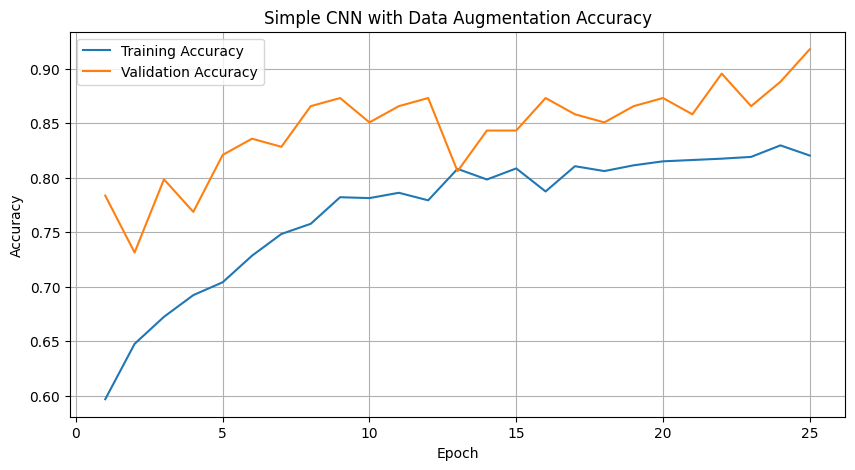

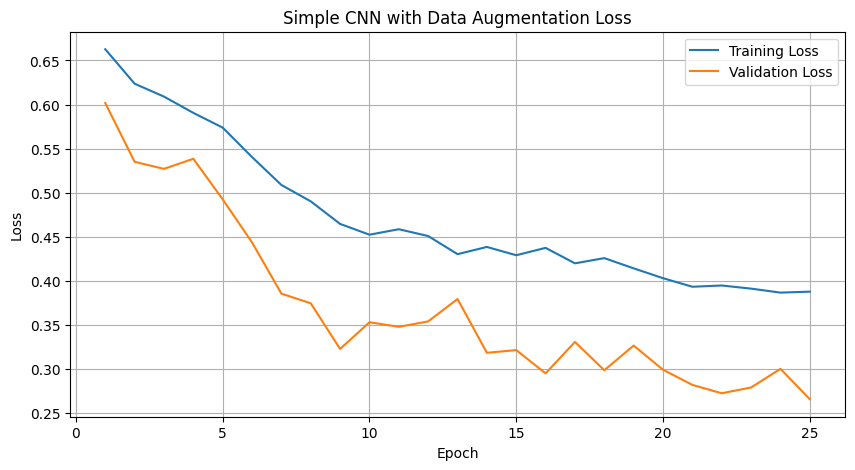

In [12]:
epochs = [h["epoch"] for h in history]
train_acc = [h["train_acc"] for h in history]
val_acc = [h["val_acc"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple CNN with Data Augmentation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple CNN with Data Augmentation Loss")
plt.legend()
plt.grid()
plt.show()

In [13]:
# Load best SimpleCNN model before testing

best_model_path = "/kaggle/working/best_simplecnn_binary.pth"

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Best model loaded.")

Best model loaded.


In [14]:
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.4644288876638984
Test Accuracy: 0.7741935483870968


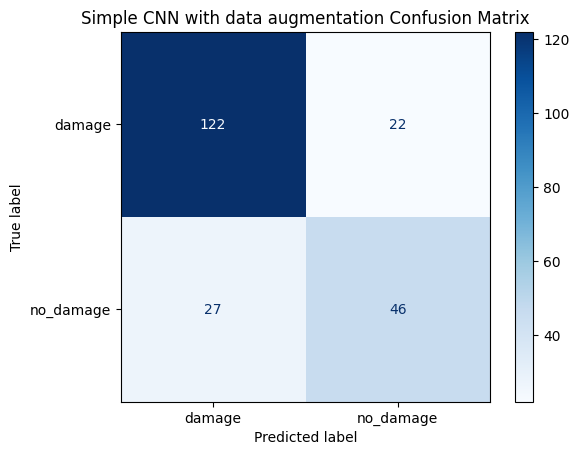

              precision    recall  f1-score   support

      damage       0.82      0.85      0.83       144
   no_damage       0.68      0.63      0.65        73

    accuracy                           0.77       217
   macro avg       0.75      0.74      0.74       217
weighted avg       0.77      0.77      0.77       217



In [20]:
class_names = train_ds.classes

cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")
plt.title("Simple CNN with Data Augmentation Confusion Matrix")
plt.show()

print(classification_report(test_labels, test_preds, target_names=class_names))

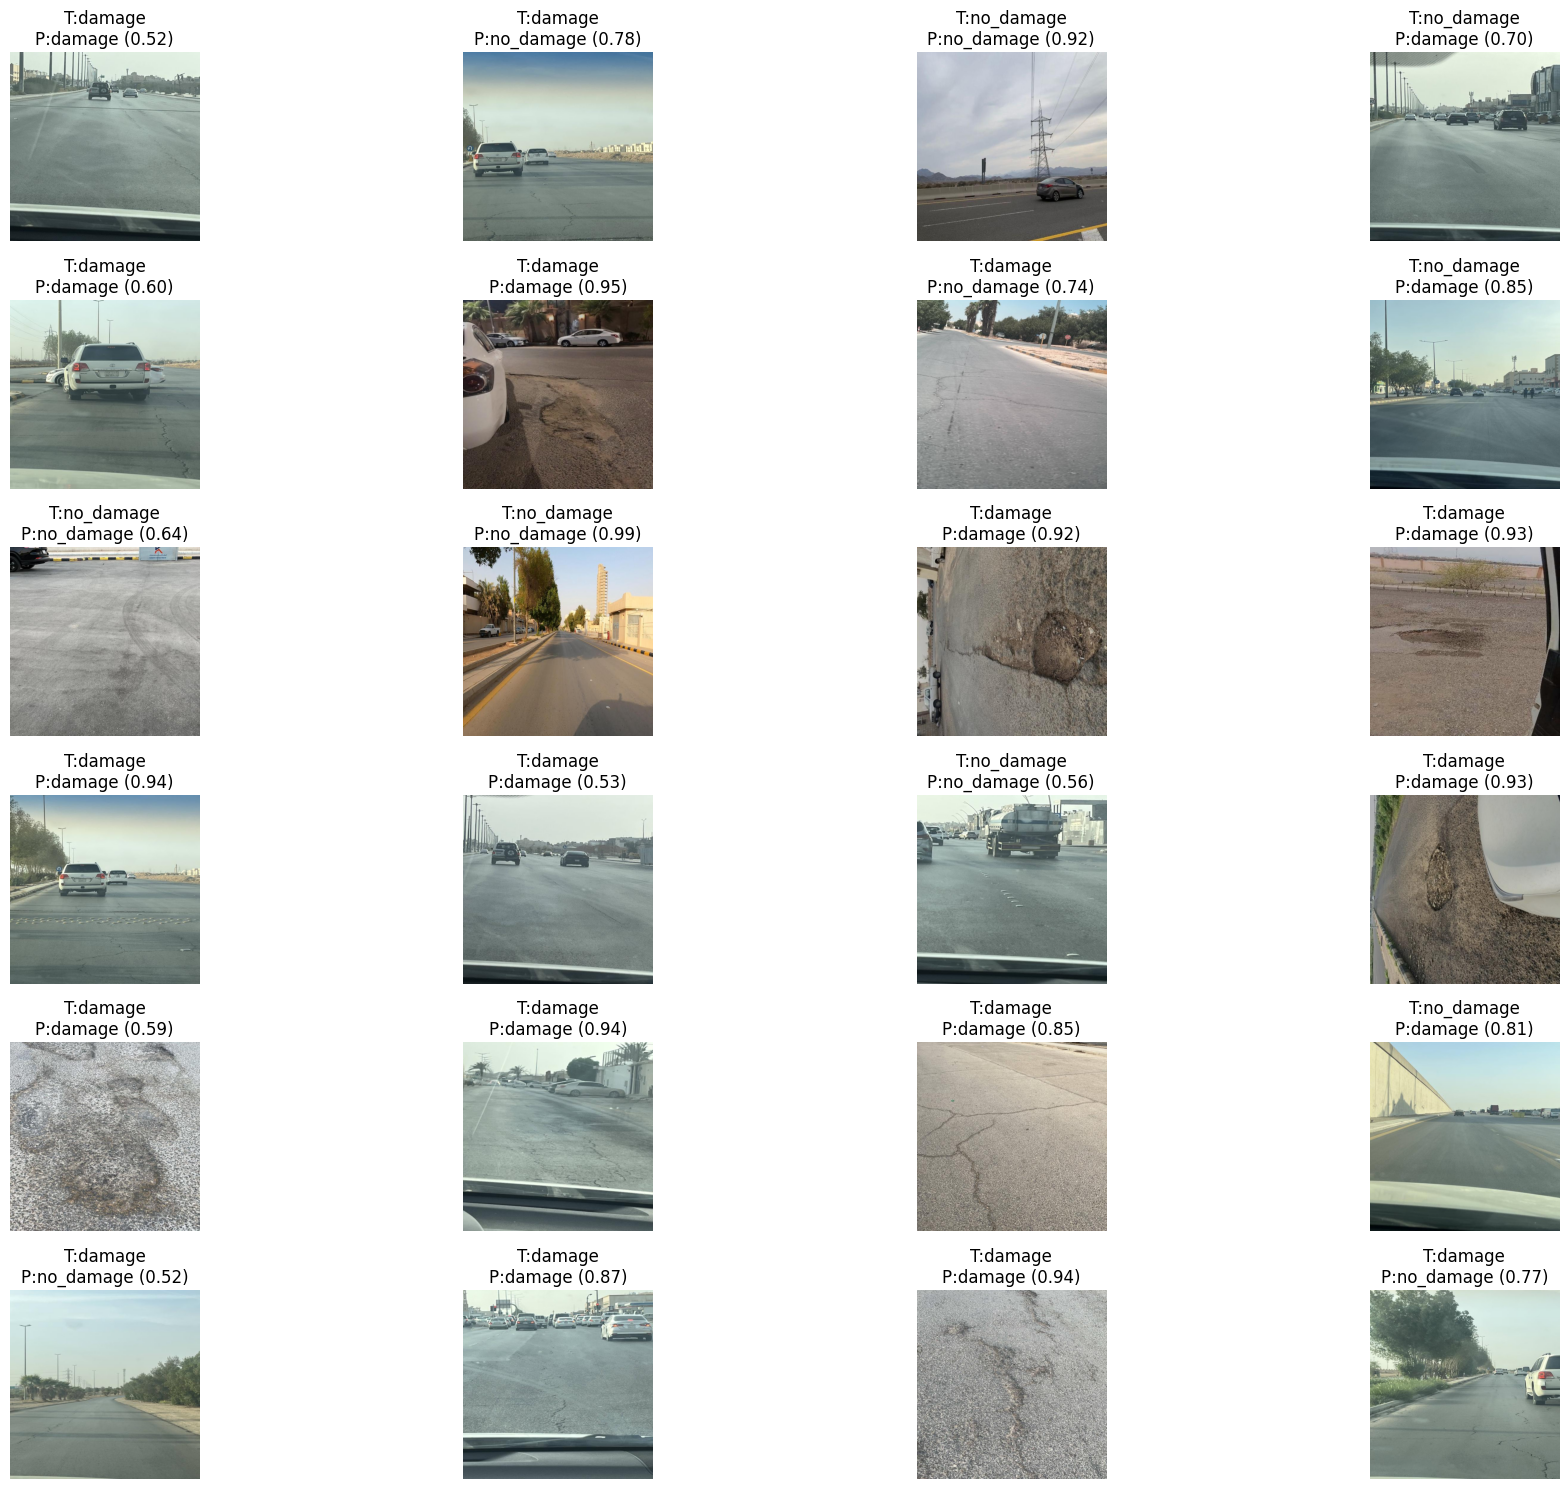

In [16]:
from PIL import Image
import cv2

idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

TEST_PATH = f"{WORK_PATH}/test"

test_image_paths = []

for cls in os.listdir(TEST_PATH):
    folder = os.path.join(TEST_PATH, cls)
    for img_name in os.listdir(folder):
        test_image_paths.append(os.path.join(folder, img_name))

sample_paths = random.sample(test_image_paths, min(24, len(test_image_paths)))

model.eval()

plt.figure(figsize=(20, 15))

for i, img_path in enumerate(sample_paths):
    img = Image.open(img_path).convert("RGB")

    input_img = eval_tfms(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_img)
        prob = torch.softmax(output, dim=1)[0]
        pred = prob.argmax().item()

    pred_class = idx_to_class[pred]
    confidence = prob[pred].item()
    true_class = os.path.basename(os.path.dirname(img_path))

    plt.subplot(6, 4, i + 1)
    plt.imshow(img)
    plt.title(f"T:{true_class}\nP:{pred_class} ({confidence:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import random

model.eval()

wrong_samples = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                wrong_samples.append({
                    "image": images[i].cpu(),
                    "true": labels[i].item(),
                    "pred": preds[i].item(),
                    "conf": probs[i][preds[i]].item()
                })

print("Total wrong:", len(wrong_samples))

Total wrong: 49


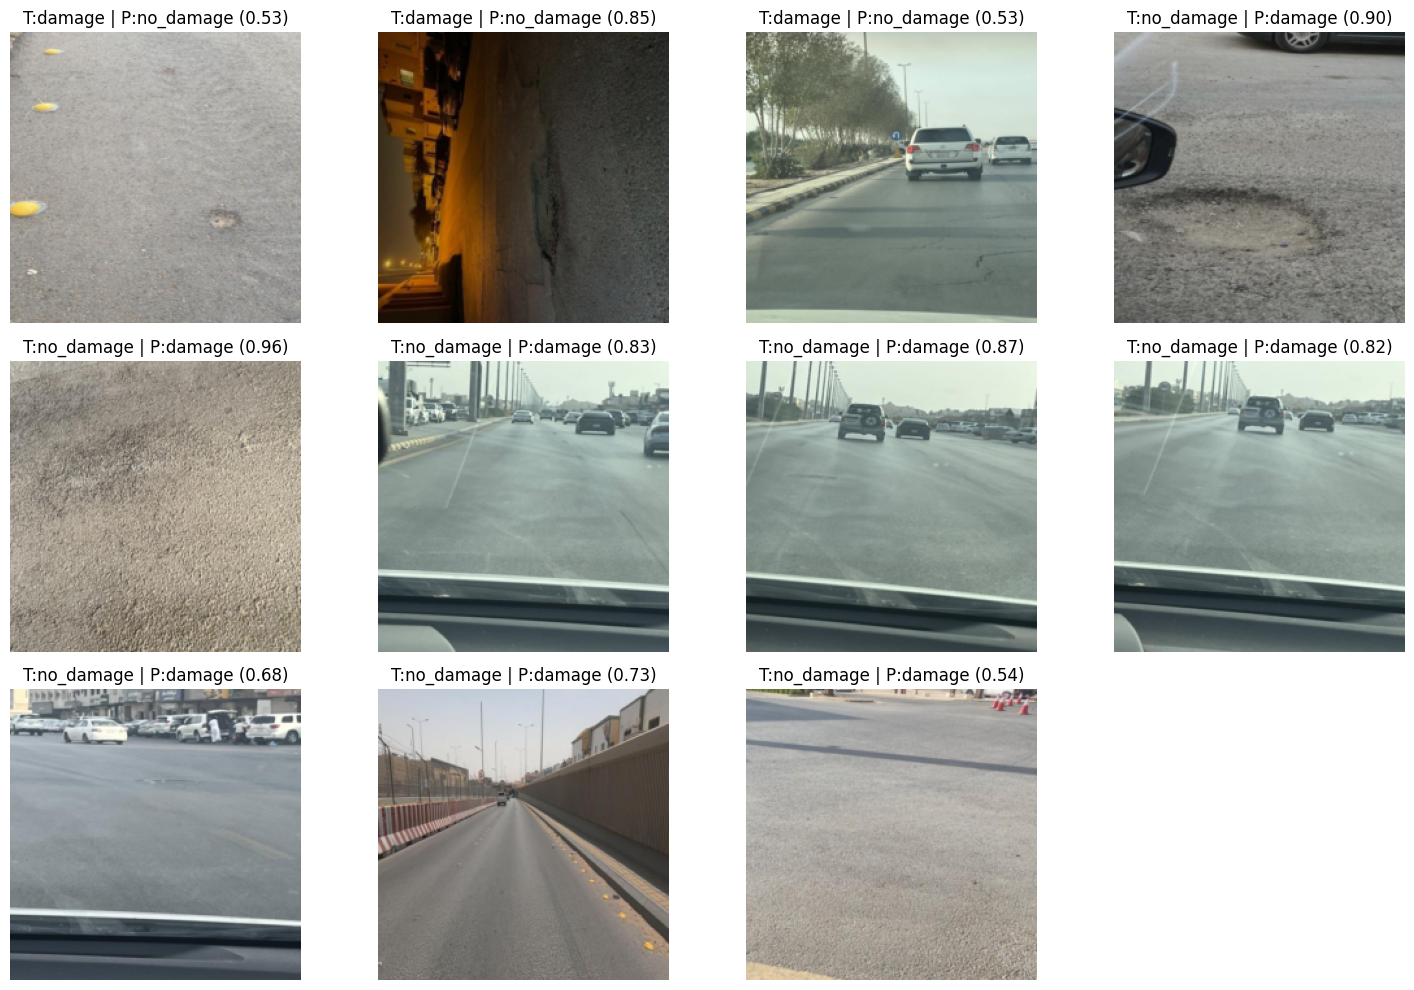

In [18]:
# Show Misclassified Images
import matplotlib.pyplot as plt
import numpy as np
import math

model.eval()

wrong_images = []
wrong_preds = []
wrong_labels = []
wrong_probs = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        wrong_idx = preds != labels

        if wrong_idx.any():
            wrong_images.extend(images[wrong_idx].cpu())
            wrong_preds.extend(preds[wrong_idx].cpu().numpy())
            wrong_labels.extend(labels[wrong_idx].cpu().numpy())
            wrong_probs.extend(probs.max(dim=1)[0][wrong_idx].cpu().numpy())


# Display wrong predictions

class_names = ['damage', 'no_damage']

num_images = min(12, len(wrong_images))

cols = 4
rows = math.ceil(num_images / cols)

plt.figure(figsize=(15, 10))

for i in range(num_images):

    img = wrong_images[i]

    img = img.permute(1, 2, 0).numpy()

    img = np.clip(img, 0, 1)

    true_class = class_names[wrong_labels[i]]
    pred_class = class_names[wrong_preds[i]]
    conf = wrong_probs[i]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)

    plt.title(f"T:{true_class} | P:{pred_class} ({conf:.2f})")

    plt.axis("off")

plt.tight_layout()
plt.show()

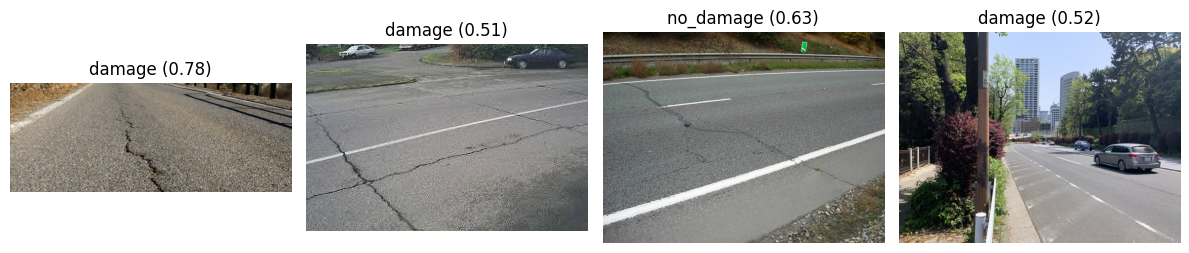

In [19]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import torch

idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

urls = [
    "https://renolith.com.au/wp-content/uploads/2024/02/Wheelpath.webp",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS1CWdOtOEmUFD4-tuvQV1Zg3dO3kkO9E_6aA&s",
    "https://www.tensarinternational.com/getattachment/a56d8c45-bdec-46ec-90af-836fdd357ec8/cracking-(1).jpg",
    "https://preview.redd.it/photos-i-took-walking-along-the-real-life-tokyo-r246-v0-a82g483453va1.jpg?width=640&crop=smart&auto=webp&s=cde1cd462b8e7b41de420e2329b49cfcd4b247d5"
]

model.eval()

plt.figure(figsize=(12, 6))

for i, url in enumerate(urls):
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        img = Image.open(BytesIO(response.content)).convert("RGB")

        input_img = eval_tfms(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(input_img)
            prob = torch.softmax(output, dim=1)[0]
            pred = prob.argmax().item()

        pred_class = idx_to_class[pred]
        confidence = prob[pred].item()

        plt.subplot(1, len(urls), i + 1)
        plt.imshow(img)
        plt.title(f"{pred_class} ({confidence:.2f})")
        plt.axis("off")

    except Exception as e:
        print(f"Error with URL {i+1}: {e}")

plt.tight_layout()
plt.show()